In [1]:
from toy_model import *
from circuit_utils import *
import wandb
import torch
import numpy as np
import plotly.io as pio
from transformer_lens import HookedTransformer

In [2]:
pio.templates.default = "plotly"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## Process 2
![Screenshot 2025-10-27 114019.png](<attachment:Screenshot 2025-10-27 114019.png>)
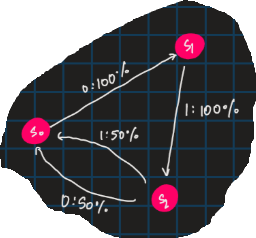

In [3]:
T0_proc2 = np.array([
    [0, 1, 0],
    [0, 0, 0],
    [0.5, 0, 0]
])
T1_proc2 = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0.5, 0, 0]
])

N_GEN = 5000
GEN_LEN = 32
dataset_proc2 = MarkovData(
    n_gen=N_GEN, 
    gen_len=GEN_LEN, 
    n_states=3, 
    d_vocab=2, 
    T_list=[T0_proc2, T1_proc2], 
    device=DEVICE
)

In [4]:
N_EPOCHS = 200
BATCH_SIZE = 64
LR = 0.05
N_LAYERS = 2
D_MODEL = 16
N_HEADS = 2
D_HEAD = 8
ATTN_ONLY = True
ACT_FN = 'silu'
MODEL_DIR = "./toy_transformer_models"
MODEL_PATH = os.path.join(MODEL_DIR, f"model_proc_2_n_layers_{N_LAYERS}_d_model_{D_MODEL}_lr_{LR}_n_heads_{N_HEADS}_batch_{BATCH_SIZE}_n_epochs_{N_EPOCHS}_attn_only_{ATTN_ONLY}.pt")
CFG_PATH = os.path.join(MODEL_DIR, "model_cfg.pt")
DATASET = dataset_proc2

In [5]:
if os.path.exists(MODEL_PATH) and os.path.exists(CFG_PATH):
    print(f"Loading existing model from {MODEL_DIR}...")
    model = load_model(MODEL_PATH, CFG_PATH, device=DEVICE)
    torch.set_grad_enabled(False)
else:
    print(f"No model found. Training a new one in {MODEL_DIR}...")
    torch.set_grad_enabled(True)
    model = train_model(
        dataset=DATASET,
        n_layers=N_LAYERS,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        d_head=D_HEAD,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        attn_only=ATTN_ONLY,
        act_fn=ACT_FN,
        optimizer_name="AdamW",
        save_every=N_EPOCHS + 1,
        print_every=N_EPOCHS // 10,
        save_dir=MODEL_DIR,
        wandb=False,
        device=DEVICE,
        track_ngrams=False,
        track_composition=False,
        track_previous_token=False,
        track_in_context=False,
        track_prefix_matching=False
    )
    torch.save(model.state_dict(), MODEL_PATH)
    print("Model training complete and saved.")
    torch.set_grad_enabled(False)

print("\nModel Configuration:")
print(model.cfg)

Loading existing model from ./toy_transformer_models...

Model Configuration:
HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'act_fn': 'silu',
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_scale': np.float64(2.8284271247461903),
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 8,
 'd_mlp': 256,
 'd_model': 16,
 'd_vocab': 2,
 'd_vocab_out': 2,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': 'cpu',
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': True,
 'initializer_range': np.float64(0.2),
 'load_in_4bit': False,
 'model_name': 'custom',
 'n_ctx': 33,
 'n_devices': 1,
 'n_heads': 2,
 'n_key_value_heads': None,
 'n_layers': 2,
 'n_params': 2048,


In [6]:
import types # We need this to add new methods to our model instance

model_vocab = ('0', '1')

print("--- Starting Patch ---")

# --- 1. Define our new, simple token-conversion functions ---

def new_to_tokens(self: HookedTransformer, text: str, **kwargs):
    """
    Overrides model.to_tokens.
    Converts a string like "01011" into a tensor([0, 1, 0, 1, 1]).
    """
    # Note: `self` will be the `model` object
    tokens = [int(char) for char in text if char in model_vocab]
    # Add a batch dimension and send to the model's device
    return torch.tensor(tokens, device=self.cfg.device).unsqueeze(0)

def new_to_str_tokens(self: HookedTransformer, tokens, **kwargs):
    """
    Overrides model.to_str_tokens.
    Converts a tensor like [0, 1, 0] into a list ["0", "1", "0"].
    """
    # Handle batches (e.g., tokens.shape == [1, 10])
    if isinstance(tokens, torch.Tensor) and tokens.dim() > 1:
        tokens = tokens[0] 
        return [str(int(t.item())) for t in tokens]
    return [str(int(t)) for t in tokens]

def new_to_single_token(self: HookedTransformer, token_str: str, **kwargs):
    """
    Overrides model.to_single_token.
    Converts a string "0" or "1" into the integer 0 or 1.
    """
    return int(token_str)

# --- 2. Create a "dummy" tokenizer object ---
# `circuit_utils.py` checks `model.tokenizer.eos_token`.
# We'll create a simple object that just has this one attribute.
class DummyTokenizer:
    # Our model doesn't have an EOS token. We'll set this to a string
    # that will never be generated, so the generation loop doesn't
    # stop early.
    eos_token = "<|NEVER_TOKEN|>"
    padding_side = "left"
    pad_token_id = 0 # Must match model.cfg.pad_token_id
    
    eos_token_id = None
    bos_token_id = None

# --- 3. Apply the patches to our `model` instance ---

# Bind our new functions as methods of the `model` object
model.to_tokens = types.MethodType(new_to_tokens, model)
model.to_str_tokens = types.MethodType(new_to_str_tokens, model)
model.to_single_token = types.MethodType(new_to_single_token, model)

# Assign the dummy tokenizer object
model.tokenizer = DummyTokenizer()

# --- 4. Configure the model to NOT use special tokens ---
# This is critical for `model.generate()` (used by `extract_activations`)
# It stops the model from trying to add BOS/EOS tokens, which it
# was not trained on.
model.cfg.bos_token_id = None
model.cfg.eos_token_id = None
model.cfg.pad_token_id = 0 # We can just use '0' as our pad token

print("--- Patch Applied Successfully ---")
print(f"model.tokenizer is now: {type(model.tokenizer)}")
print(f"model.tokenizer.eos_token = {model.tokenizer.eos_token}")
print(f"model.cfg.bos_token_id = {model.cfg.bos_token_id}")
print(f"\nTest model.to_tokens('0110') -> {model.to_tokens('0110')}")
print(f"Test model.to_str_tokens([0, 1, 1, 0]) -> {model.to_str_tokens([0, 1, 1, 0])}")
print(f"Test model.to_single_token('1') -> {model.to_single_token('1')}")

--- Starting Patch ---
--- Patch Applied Successfully ---
model.tokenizer is now: <class '__main__.DummyTokenizer'>
model.tokenizer.eos_token = <|NEVER_TOKEN|>
model.cfg.bos_token_id = None

Test model.to_tokens('0110') -> tensor([[0, 1, 1, 0]])
Test model.to_str_tokens([0, 1, 1, 0]) -> ['0', '1', '1', '0']
Test model.to_single_token('1') -> 1


In [7]:
# Use a sample from the dataset as our clean prompt
clean_prompt_tokens = DATASET.data[0][:-1] # Use all but the last token
clean_prompt_str = model.to_str_tokens(clean_prompt_tokens)
clean_prompt = "".join(clean_prompt_str)

# Create a "corrupted" prompt (e.g., a different sequence)
corrupted_prompt_tokens = DATASET.data[1][:-1]
corrupted_prompt_str = model.to_str_tokens(corrupted_prompt_tokens)
corrupted_prompt = "".join(corrupted_prompt_str)

print(f"Clean Prompt:     '{clean_prompt}'")
print(f"Corrupted Prompt: '{corrupted_prompt}'")

# --- Helper function to replace extract_activations ---

def get_cache_data_from_prompt(model, prompt):
    """
    Runs model.run_with_cache on a prompt and returns a
    dictionary in the same format as extract_activations.
    
    This version KEEPS the original ActivationCache and batch
    dimensions, which is the correct format.
    """
    # Manually tokenize the prompt
    tokens = model.to_tokens(prompt) # Shape: [1, seq_len]
    
    # Run the model and cache all activations
    final_logits, cache = model.run_with_cache(
        tokens,
        prepend_bos=False # Our model wasn't trained with BOS
    )
    
    # Re-create the dictionary structure that circuit_utils expects
    return {
        'activations': cache, # The *original* ActivationCache object
        'final_logits': final_logits.cpu(), # [1, seq_len, d_vocab]
        'tokens': tokens.cpu(), # [1, seq_len]
        'str_tokens': model.to_str_tokens(tokens), # List of strings
        'seq_len': tokens.shape[1],
        'input_text': prompt,
        'generated_str_tokens': [],
        'input_str_tokens': model.to_str_tokens(tokens),
    }

# --- Use our new helper function ---
clean_cache_data = get_cache_data_from_prompt(model, clean_prompt)
corrupted_cache_data = get_cache_data_from_prompt(model, corrupted_prompt)

print(f"\nClean Run Tokens ({len(clean_cache_data['str_tokens'])}):")
print(clean_cache_data['str_tokens'])

# Get the model's prediction for the *next* token at the *last* position
last_pos_logits = clean_cache_data['final_logits'][0, -1, :] # Index batch 0
prediction_id = last_pos_logits.argmax().item()
prediction_str = model.to_str_tokens([prediction_id])[0]

print(f"\nModel prediction (at final pos) on clean prompt: '{prediction_str}'")

Clean Prompt:     '1101001101101001001001001101101'
Corrupted Prompt: '1011011011011011011010011010010'

Clean Run Tokens (31):
['1', '1', '0', '1', '0', '0', '1', '1', '0', '1', '1', '0', '1', '0', '0', '1', '0', '0', '1', '0', '0', '1', '0', '0', '1', '1', '0', '1', '1', '0', '1']

Model prediction (at final pos) on clean prompt: '1'


In [8]:
fig = plot_logit_lens_heatmap(
    model,
    cache_data=clean_cache_data,
    start=0, # Start from the first token
    hook_filter='resid_post',
    figsize=(20, 8)
)
fig.show()

In [9]:
k=2
print("--- Interactive Logit Lens Widget ---")
create_interactive_widget(model, clean_cache_data, k=k)

--- Interactive Logit Lens Widget ---


interactive(children=(IntSlider(value=0, description='Layer:', max=1, style=SliderStyle(description_width='ini…


Sequence (31 tokens):
 0: '1'
 1: '1'
 2: '0'
 3: '1'
 4: '0'
 5: '0'
 6: '1'
 7: '1'
 8: '0'
 9: '1'
10: '1'
11: '0'
12: '1'
13: '0'
14: '0'
15: '1'
16: '0'
17: '0'
18: '1'
19: '0'
20: '0'
21: '1'
22: '0'
23: '0'
24: '1'
25: '1'
26: '0'
27: '1'
28: '1'
29: '0'
30: '1'


In [10]:
# --- Use create_attention_widget ---
print("--- Interactive Attention Pattern Widget ---")
create_attention_widget(model, clean_cache_data, figsize=(40, 30))

--- Interactive Attention Pattern Widget ---


interactive(children=(IntSlider(value=0, description='Layer:', max=1, style=SliderStyle(description_width='ini…


Full Sequence (31 tokens):
 0: '1'
 1: '1'
 2: '0'
 3: '1'
 4: '0'
 5: '0'
 6: '1'
 7: '1'
 8: '0'
 9: '1'
10: '1'
11: '0'
12: '1'
13: '0'
14: '0'
15: '1'
16: '0'
17: '0'
18: '1'
19: '0'
20: '0'
21: '1'
22: '0'
23: '0'
24: '1'
25: '1'
26: '0'
27: '1'
28: '1'
29: '0'
30: '1'


## Process 1 
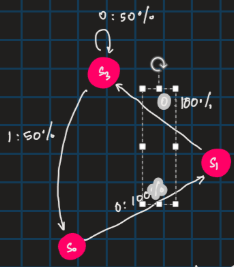

In [11]:
T0_proc1 = np.array([
    [0, 1, 0],
    [0, 0, 1], 
    [0, 0, 0.5]
])
T1_proc1 = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0.5, 0, 0]
])

N_GEN = 5000
GEN_LEN = 32
dataset_proc1 = MarkovData(
    n_gen=N_GEN, 
    gen_len=GEN_LEN, 
    n_states=3, 
    d_vocab=2, 
    T_list=[T0_proc1, T1_proc1], 
    device=DEVICE
)

In [12]:
N_EPOCHS = 200
BATCH_SIZE = 64
LR = 0.05
N_LAYERS = 2
D_MODEL = 16
N_HEADS = 2
D_HEAD = 8
ATTN_ONLY = True
ACT_FN = 'silu'
MODEL_DIR = "./toy_transformer_models"
MODEL_PATH = os.path.join(MODEL_DIR, f"model_proc_1_n_layers_{N_LAYERS}_d_model_{D_MODEL}_lr_{LR}_n_heads_{N_HEADS}_batch_{BATCH_SIZE}_n_epochs_{N_EPOCHS}_attn_only_{ATTN_ONLY}.pt")
CFG_PATH = os.path.join(MODEL_DIR, "model_cfg.pt")
DATASET = dataset_proc1

In [13]:
if os.path.exists(MODEL_PATH) and os.path.exists(CFG_PATH):
    print(f"Loading existing model from {MODEL_DIR}...")
    model = load_model(MODEL_PATH, CFG_PATH, device=DEVICE)
    torch.set_grad_enabled(False)
else:
    print(f"No model found. Training a new one in {MODEL_DIR}...")
    torch.set_grad_enabled(True)
    model = train_model(
        dataset=DATASET,
        n_layers=N_LAYERS,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        d_head=D_HEAD,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        attn_only=ATTN_ONLY,
        act_fn=ACT_FN,
        optimizer_name="AdamW",
        save_every=N_EPOCHS + 1,
        print_every=N_EPOCHS // 10,
        save_dir=MODEL_DIR,
        wandb=False,
        device=DEVICE,
        track_ngrams=False,
        track_composition=False,
        track_previous_token=False,
        track_in_context=False,
        track_prefix_matching=False
    )
    torch.save(model.state_dict(), MODEL_PATH)
    print("Model training complete and saved.")
    torch.set_grad_enabled(False)

print("\nModel Configuration:")
print(model.cfg)

Loading existing model from ./toy_transformer_models...

Model Configuration:
HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'act_fn': 'silu',
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_scale': np.float64(2.8284271247461903),
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 8,
 'd_mlp': 256,
 'd_model': 16,
 'd_vocab': 2,
 'd_vocab_out': 2,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': 'cpu',
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': True,
 'initializer_range': np.float64(0.2),
 'load_in_4bit': False,
 'model_name': 'custom',
 'n_ctx': 33,
 'n_devices': 1,
 'n_heads': 2,
 'n_key_value_heads': None,
 'n_layers': 2,
 'n_params': 2048,


In [14]:
model_vocab = ('0', '1')

print("--- Starting Patch ---")

model.to_tokens = types.MethodType(new_to_tokens, model)
model.to_str_tokens = types.MethodType(new_to_str_tokens, model)
model.to_single_token = types.MethodType(new_to_single_token, model)

model.tokenizer = DummyTokenizer()
model.cfg.bos_token_id = None
model.cfg.eos_token_id = None
model.cfg.pad_token_id = 0

print("--- Patch Applied Successfully ---")
print(f"model.tokenizer is now: {type(model.tokenizer)}")
print(f"model.tokenizer.eos_token = {model.tokenizer.eos_token}")
print(f"model.cfg.bos_token_id = {model.cfg.bos_token_id}")
print(f"\nTest model.to_tokens('0110') -> {model.to_tokens('0110')}")
print(f"Test model.to_str_tokens([0, 1, 1, 0]) -> {model.to_str_tokens([0, 1, 1, 0])}")
print(f"Test model.to_single_token('1') -> {model.to_single_token('1')}")

--- Starting Patch ---
--- Patch Applied Successfully ---
model.tokenizer is now: <class '__main__.DummyTokenizer'>
model.tokenizer.eos_token = <|NEVER_TOKEN|>
model.cfg.bos_token_id = None

Test model.to_tokens('0110') -> tensor([[0, 1, 1, 0]])
Test model.to_str_tokens([0, 1, 1, 0]) -> ['0', '1', '1', '0']
Test model.to_single_token('1') -> 1


In [15]:
clean_prompt_tokens = DATASET.data[0][:-1] # Use all but the last token
clean_prompt_str = model.to_str_tokens(clean_prompt_tokens)
clean_prompt = "".join(clean_prompt_str)

clean_cache_data = get_cache_data_from_prompt(model, clean_prompt)

print(f"\nClean Run Tokens ({len(clean_cache_data['str_tokens'])}):")
print(clean_cache_data['str_tokens'])

last_pos_logits = clean_cache_data['final_logits'][0, -1, :]
prediction_id = last_pos_logits.argmax().item()
prediction_str = model.to_str_tokens([prediction_id])[0]

print(f"\nModel prediction (at final pos) on clean prompt: '{prediction_str}'")


Clean Run Tokens (31):
['0', '1', '0', '0', '0', '0', '1', '0', '0', '0', '1', '0', '0', '0', '1', '0', '0', '0', '0', '0', '1', '0', '0', '1', '0', '0', '1', '0', '0', '1', '0']

Model prediction (at final pos) on clean prompt: '0'


In [16]:
fig = plot_logit_lens_heatmap(
    model,
    cache_data=clean_cache_data,
    start=0, # Start from the first token
    hook_filter='resid_post',
    figsize=(20, 8)
)
fig.show()

In [17]:
k=2
print("--- Interactive Logit Lens Widget ---")
create_interactive_widget(model, clean_cache_data, k=k)

--- Interactive Logit Lens Widget ---


interactive(children=(IntSlider(value=0, description='Layer:', max=1, style=SliderStyle(description_width='ini…


Sequence (31 tokens):
 0: '0'
 1: '1'
 2: '0'
 3: '0'
 4: '0'
 5: '0'
 6: '1'
 7: '0'
 8: '0'
 9: '0'
10: '1'
11: '0'
12: '0'
13: '0'
14: '1'
15: '0'
16: '0'
17: '0'
18: '0'
19: '0'
20: '1'
21: '0'
22: '0'
23: '1'
24: '0'
25: '0'
26: '1'
27: '0'
28: '0'
29: '1'
30: '0'


In [ ]:
# --- Use create_attention_widget ---
print("--- Interactive Attention Pattern Widget ---")
create_attention_widget(model, clean_cache_data, figsize=(15, 10))

--- Interactive Attention Pattern Widget ---


interactive(children=(IntSlider(value=0, description='Layer:', max=1, style=SliderStyle(description_width='ini…


Full Sequence (31 tokens):
 0: '0'
 1: '1'
 2: '0'
 3: '0'
 4: '0'
 5: '0'
 6: '1'
 7: '0'
 8: '0'
 9: '0'
10: '1'
11: '0'
12: '0'
13: '0'
14: '1'
15: '0'
16: '0'
17: '0'
18: '0'
19: '0'
20: '1'
21: '0'
22: '0'
23: '1'
24: '0'
25: '0'
26: '1'
27: '0'
28: '0'
29: '1'
30: '0'
